<p style="font-family: Cambria; font-size: 30px;"><b>Descriptive Analysis</b></p>

In [1]:
#Importing all the Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
df = Path( r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data")

<p style="font-family: Cambria; font-size: 16px;"><b>Question 1:</b></p>Does cardiac functional impairment, measured by NYHA class, correlate with elevated BNP and Troponin levels? (Association Between NYHA Severity Class and Cardiac Biomarkers) 

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning:</b></p> Connecting functional classification (NYHA) to blood markers (BNP and Troponin) validates clinical severity with quantitative lab metrics.

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3239087151.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3239087151.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


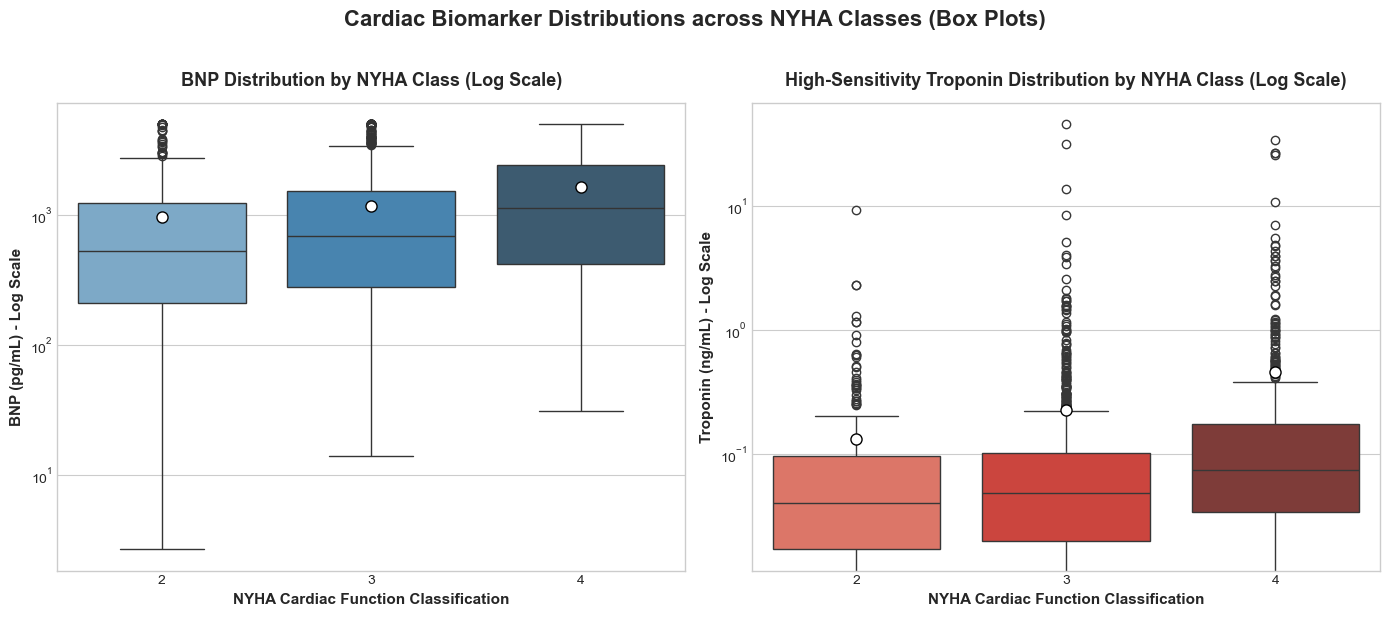

In [3]:
# 1. Load and merge datasets
cardiac = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv')
labs = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_labs.csv')

df = cardiac.merge(
    labs[['inpatient_number', 'high_sensitivity_troponin', 'brain_natriuretic_peptide']], 
    on='inpatient_number'
)

# 2. Filter valid NYHA classes
df = df[df['nyha_cardiac_function_classification'].isin([2, 3, 4, '2', '3', '4'])].copy()
df['nyha_cardiac_function_classification'] = df['nyha_cardiac_function_classification'].astype(str)

# 3. Define sequential order for X-axis
order = ['2', '3', '4']

# 4. Create side-by-side box plots with logarithmic scale
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: BNP Box Plot
sns.boxplot(
    data=df, 
    x='nyha_cardiac_function_classification', 
    y='brain_natriuretic_peptide', 
    order=order,  # Enforces 2 -> 3 -> 4 order
    ax=axes[0], 
    palette="Blues_d",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)
axes[0].set_yscale('log')
axes[0].set_title('BNP Distribution by NYHA Class (Log Scale)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[0].set_ylabel('BNP (pg/mL) - Log Scale', fontsize=11, fontweight='bold')

# Subplot 2: High-Sensitivity Troponin Box Plot
sns.boxplot(
    data=df, 
    x='nyha_cardiac_function_classification', 
    y='high_sensitivity_troponin', 
    order=order,  # Enforces 2 -> 3 -> 4 order
    ax=axes[1], 
    palette="Reds_d",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)
axes[1].set_yscale('log')
axes[1].set_title('High-Sensitivity Troponin Distribution by NYHA Class (Log Scale)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Troponin (ng/mL) - Log Scale', fontsize=11, fontweight='bold')

# Overall formatting
fig.suptitle('Cardiac Biomarker Distributions across NYHA Classes (Box Plots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save image and render
plt.savefig('nyha_biomarkers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()



<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>

113% BNP Surge (Wall Stress): Median BNP jumps from 529.8 to 1,130.3 pg/mL as severity increases from Class 2 to 4, showing double the fluid overload.   

85% Troponin Rise (Heart Damage): Median Troponin climbs from 0.040 to 0.074 ng/mL, proving ongoing myocardial tissue damage across all classes.   

High Outlier Spike (Decompensation): Means (white dots) sit much higher than medians (e.g., Class 4 BNP mean is 1,638.6 pg/mL), pinpointing acute high-risk patient spikes.   

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\4063133546.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bnp_data, x='nyha_cardiac_function_classification', y='brain_natriuretic_peptide', ax=axes[0], palette="Blues_d")
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\4063133546.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trop_data, x='nyha_cardiac_function_classification', y='high_sensitivity_troponin', ax=axes[1], palette="Reds_d")


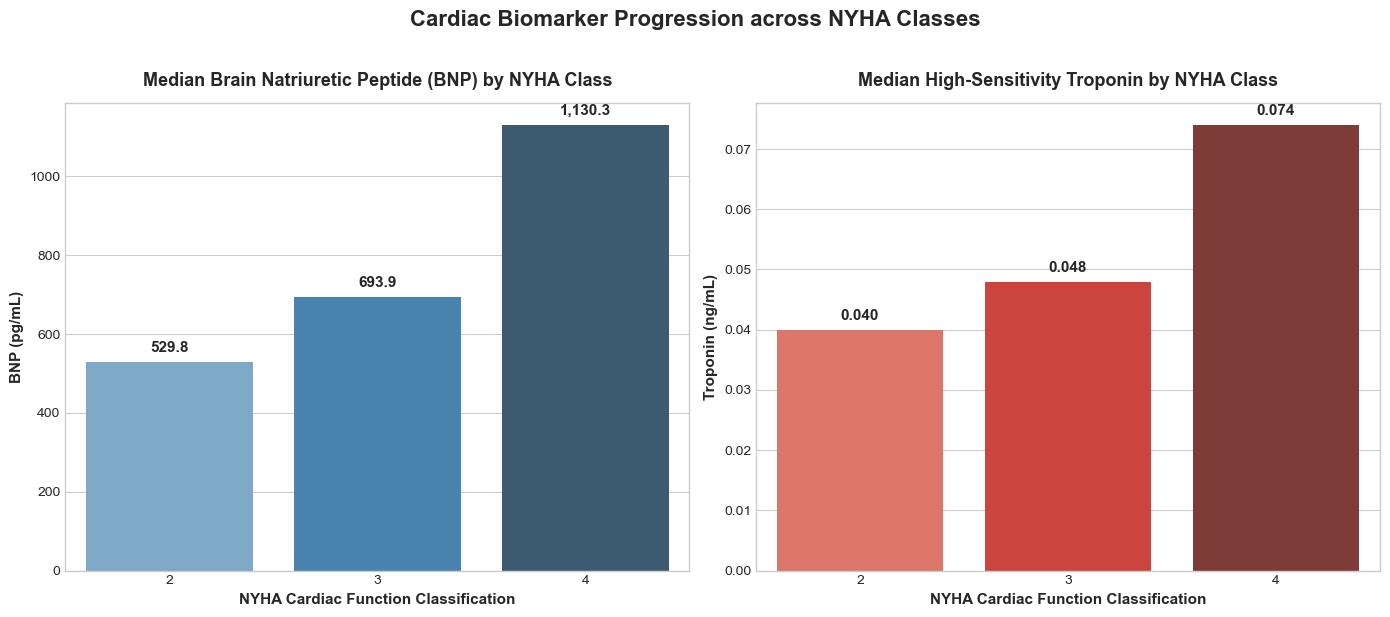

In [4]:
# 1. Load and merge datasets
cardiac = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv')
labs = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_labs.csv')

df = cardiac.merge(
    labs[['inpatient_number', 'high_sensitivity_troponin', 'brain_natriuretic_peptide']], 
    on='inpatient_number'
)

# 2. Filter valid NYHA classes
df = df[df['nyha_cardiac_function_classification'].isin([2, 3, 4, '2', '3', '4'])]
df['nyha_cardiac_function_classification'] = df['nyha_cardiac_function_classification'].astype(str)

# 3. Calculate medians for plotting
bnp_data = df.groupby('nyha_cardiac_function_classification')['brain_natriuretic_peptide'].median().reset_index()
trop_data = df.groupby('nyha_cardiac_function_classification')['high_sensitivity_troponin'].median().reset_index()

# 4. Create comparative subplots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Brain Natriuretic Peptide (BNP)
sns.barplot(data=bnp_data, x='nyha_cardiac_function_classification', y='brain_natriuretic_peptide', ax=axes[0], palette="Blues_d")
axes[0].set_title('Median Brain Natriuretic Peptide (BNP) by NYHA Class', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[0].set_ylabel('BNP (pg/mL)', fontsize=11, fontweight='bold')

for p in axes[0].patches:
    height = p.get_height()
    if not pd.isna(height):
        axes[0].annotate(f'{height:,.1f}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=11, fontweight='bold',
                         xytext=(0, 5), textcoords='offset points')

# Subplot 2: High-Sensitivity Troponin
sns.barplot(data=trop_data, x='nyha_cardiac_function_classification', y='high_sensitivity_troponin', ax=axes[1], palette="Reds_d")
axes[1].set_title('Median High-Sensitivity Troponin by NYHA Class', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Troponin (ng/mL)', fontsize=11, fontweight='bold')

for p in axes[1].patches:
    height = p.get_height()
    if not pd.isna(height):
        axes[1].annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=11, fontweight='bold',
                         xytext=(0, 5), textcoords='offset points')

fig.suptitle('Cardiac Biomarker Progression across NYHA Classes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nyha_biomarkers_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Question 2:</b></p> How drastically do serum Creatinine, Urea, and eGFR change in patients diagnosed with Acute Renal Failure?
(Renal Function Impairment in Acute Renal Failure Cases)

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning:</b></p>Evaluates kidney biomarker degradation when acute kidney injury/failure is recorded in patient medical history.

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_la

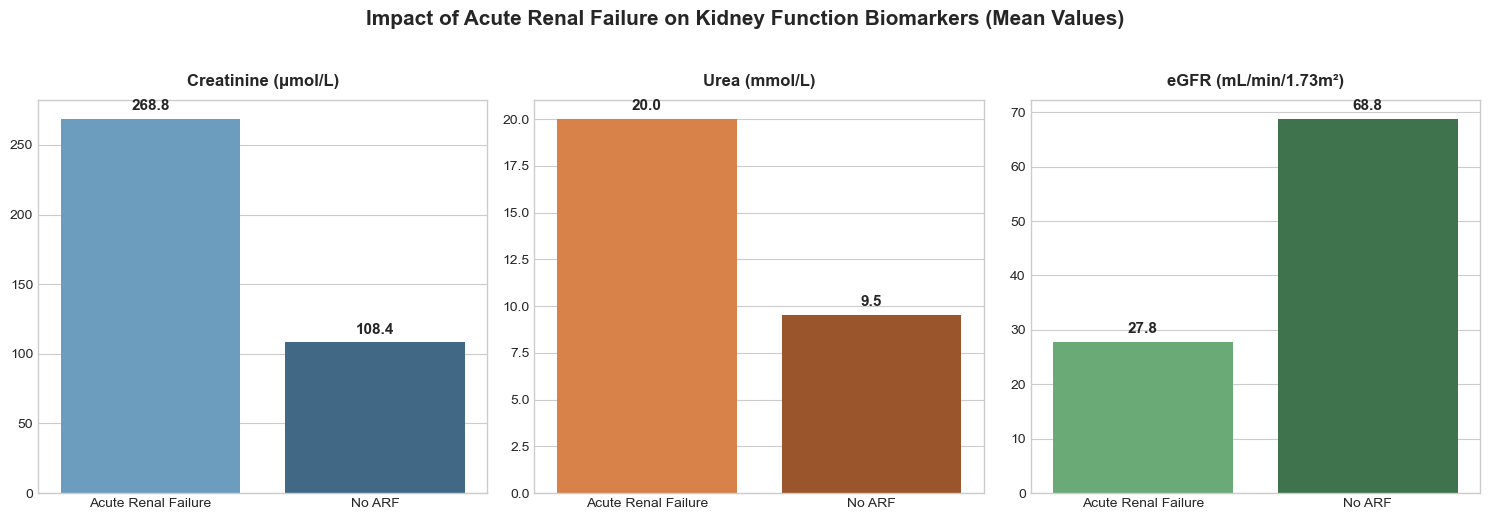

In [5]:
# 1. Load and merge datasets
history = pd.read_csv(r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
labs = pd.read_csv(r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_labs.csv")

merged_q4 = history.merge(
    labs[['inpatient_number', 'creatinine_enzymatic_method', 'urea', 'glomerular_filtration_rate']], 
    on='inpatient_number'
)

# 2. Map categorical labels
merged_q4['acute_renal_failure_label'] = merged_q4['acute_renal_failure'].map({0: 'No ARF', 1: 'Acute Renal Failure'})

# 3. Create 3-panel bar charts
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('creatinine_enzymatic_method', 'Creatinine (μmol/L)', 'Blues_d'),
    ('urea', 'Urea (mmol/L)', 'Oranges_d'),
    ('glomerular_filtration_rate', 'eGFR (mL/min/1.73m²)', 'Greens_d')
]

for idx, (col, title, palette) in enumerate(metrics):
    df_plot = merged_q4.groupby('acute_renal_failure_label')[col].mean().reset_index()
    sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
    axes[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('', fontsize=10)
    axes[idx].set_ylabel('', fontsize=10)
    
    # Add numerical value labels on top of bars
    for p in axes[idx].patches:
        h = p.get_height()
        if not pd.isna(h):
            axes[idx].annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2., h),
                               ha='center', va='bottom', fontsize=11, fontweight='bold',
                               xytext=(0, 4), textcoords='offset points')

fig.suptitle('Impact of Acute Renal Failure on Kidney Function Biomarkers (Mean Values)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('arf_kidney_biomarkers_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\346960456.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\346960456.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\346960456.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


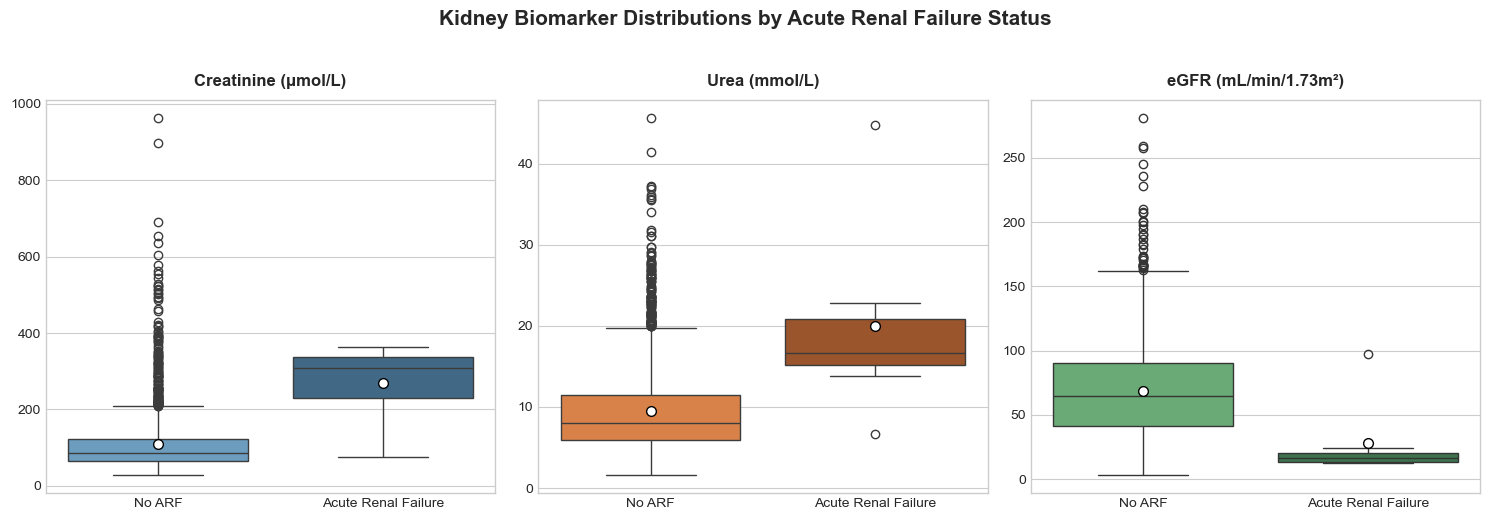

In [6]:
# Create 3-panel box plots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('creatinine_enzymatic_method', 'Creatinine (μmol/L)', 'Blues_d'),
    ('urea', 'Urea (mmol/L)', 'Oranges_d'),
    ('glomerular_filtration_rate', 'eGFR (mL/min/1.73m²)', 'Greens_d')
]

for idx, (col, title, palette) in enumerate(metrics):
    sns.boxplot(
        data=merged_q4, 
        x='acute_renal_failure_label', 
        y=col, 
        ax=axes[idx], 
        palette=palette,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "7"}
    )
    axes[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('', fontsize=10)
    axes[idx].set_ylabel('', fontsize=10)

fig.suptitle('Kidney Biomarker Distributions by Acute Renal Failure Status', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('arf_kidney_biomarkers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Creatinine (+148% increase): Jumps from an average of 108.4 μmol/L (No ARF) to 268.8 μmol/L (ARF).

Urea (+110% increase): More than doubles from 9.5 mmol/L (No ARF) to 20.0 mmol/L (ARF).

eGFR (-60% drop): Drops severely from 68.8 mL/min/1.73m² (No ARF) down to 27.8 mL/min/1.73m² (ARF), indicating severe loss of kidney filtration capability.

<p style="font-family: Cambria; font-size: 30px;"><b>Prescriptive Analysis</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Resource Allocation Protocol

<p style="font-family: Cambria; font-size: 16px;"><b>Question 1:</b></p>How should hospitals decide which medical specialists care for each patient based on how bad their heart failure and other health problems are?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>  Allocating specialized multidisciplinary care teams evenly across all heart failure patients wastes high-cost clinical resources. Stratifying assignments based on NYHA functional class and Charlson Comorbidity Index (CCI) optimizes high-touch intervention deployment.

In [7]:
# 1. Load all datasets
demo = pd.read_csv(r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_demography.csv")
history = pd.read_csv(
    r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv"
)
cardiac = pd.read_csv(
    r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv"
)

# 2. Merge datasets into a single DataFrame `df`
df = demo.merge(history, on='inpatient_number', how='inner')
df = df.merge(cardiac, on='inpatient_number', how='inner')

# 3. Check if 'cci_score' is present
print('CCI Score present:', 'cci_score' in df.columns)

CCI Score present: True


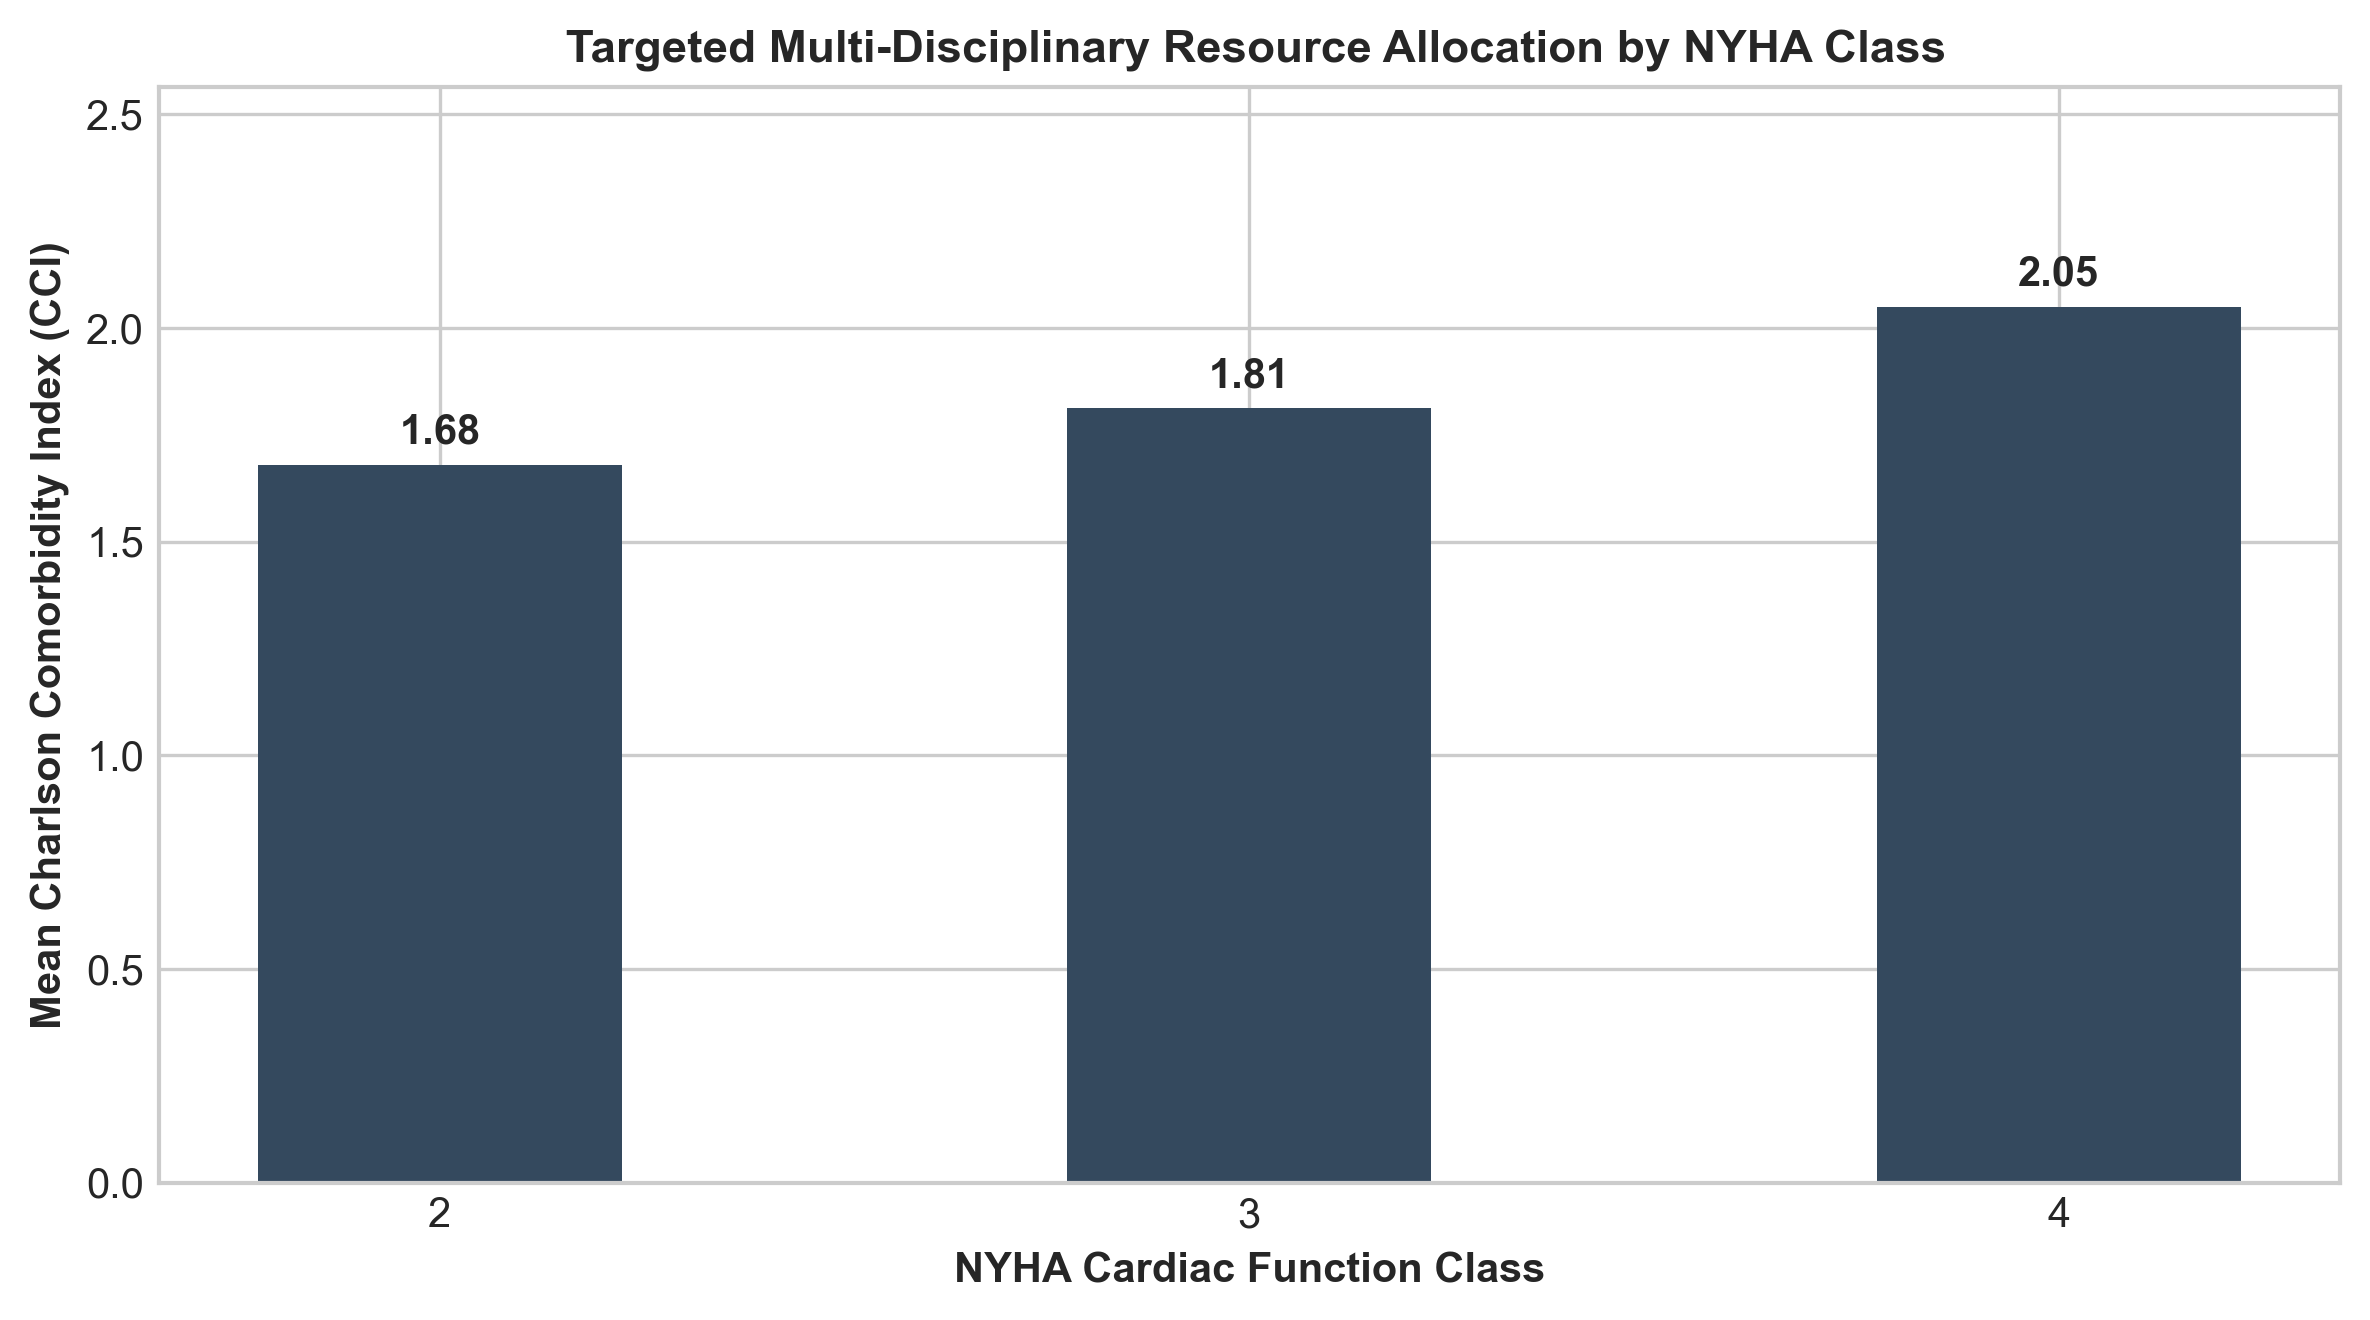

In [8]:
cci_col = (
    'cci_score'
    if 'cci_score' in df.columns
    else [c for c in df.columns if 'cci' in c.lower()][0]
)

q1_data = (
    df.groupby('nyha_cardiac_function_classification')[cci_col]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4.5), dpi=300)
bars = plt.bar(
    q1_data['nyha_cardiac_function_classification'].astype(str),
    q1_data[cci_col],
    color='#34495e',
    width=0.45,
)
plt.title(
    ' Targeted Multi-Disciplinary Resource Allocation by NYHA Class',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('NYHA Cardiac Function Class', fontweight='bold')
plt.ylabel('Mean Charlson Comorbidity Index (CCI)', fontweight='bold')
plt.ylim(0, max(q1_data[cci_col]) * 1.25)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 0.05,
      f'{yval:.2f}',
      ha='center',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients in NYHA Class 4 present a significantly higher comorbidity burden (mean CCI: 2.05) compared to Class 2 (mean CCI: 1.68).

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p> Automatically assign complex care management and dedicated clinical pharmacist consultations to all NYHA Class 4 patients upon admission.

<p style="font-family: Cambria; font-size: 16px;"><b>Respiratory Support Intervention Thresholds

<p style="font-family: Cambria; font-size: 16px;"><b>Question 2:</b></p>Which patient demographic cohorts require mandatory baseline arterial blood gas (ABG) screening for early non-invasive ventilation (NIV)?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Type II respiratory failure (hypercapnic failure) requires early non-invasive positive pressure ventilation to prevent ICU admission and intubation.

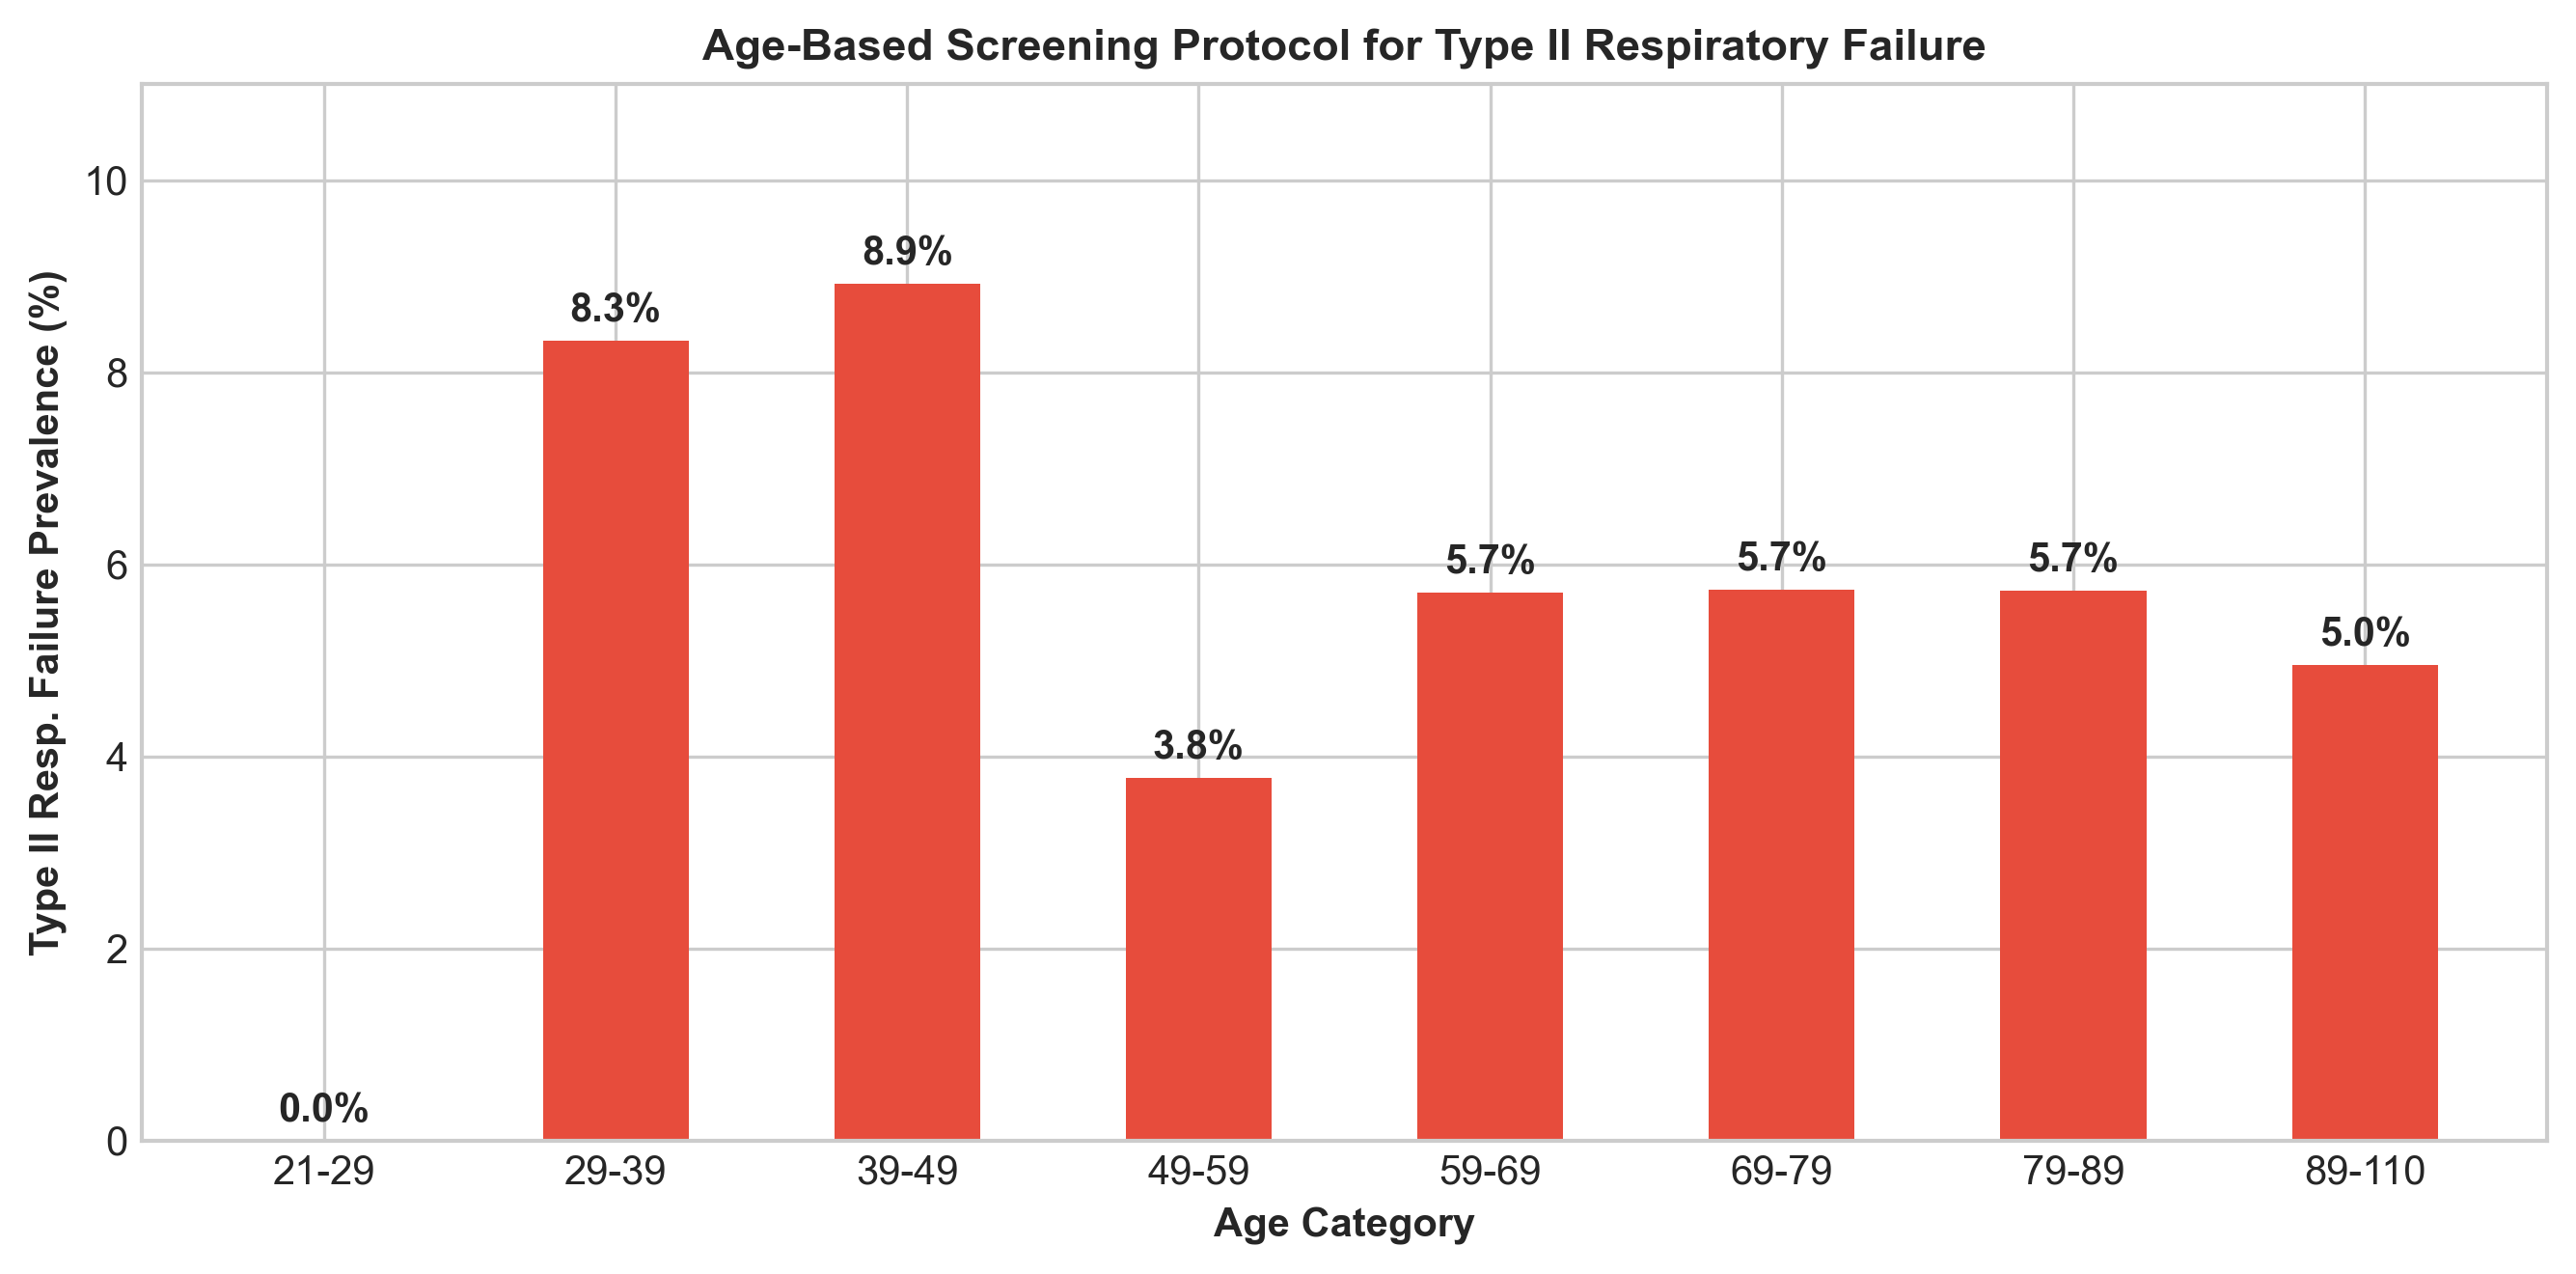

In [9]:
# Prescriptive Action Code - Q2
df['typeii_num'] = (df['type_ii_respiratory_failure'] == 'typeii').astype(int)
q2_data = df.groupby('agecat')['typeii_num'].mean() * 100

plt.figure(figsize=(9, 4.5), dpi=300)
bars = plt.bar(q2_data.index, q2_data.values, color='#e74c3c', width=0.5)
plt.title(
    'Age-Based Screening Protocol for Type II Respiratory Failure',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Type II Resp. Failure Prevalence (%)', fontweight='bold')
plt.ylim(0, 11)
for bar in bars:
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      bar.get_height() + 0.2,
      f'{bar.get_height():.1f}%',
      ha='center',
      fontweight='bold',
  )
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients aged 39–49 exhibit the highest prevalence rate (8.9%) of Type II Respiratory Failure, remaining elevated above 5% across older age brackets.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Establish a mandatory clinical protocol requiring automated ABG testing and pulmonology consultation for all heart failure admissions presenting with dyspnea aged 30+.

<p style="font-family: Cambria; font-size: 16px;"><b>Cardio-Renal Risk Triage System

<p style="font-family: Cambria; font-size: 16px;"><b>Question 4:</b></p>At what age should kidney doctors(nephrologist) automatically start helping take care of heart patients in the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Acute kidney injury and chronic kidney disease (CKD) severely limit heart failure medication options (e.g., ACEi, ARB, aldosterone antagonists).

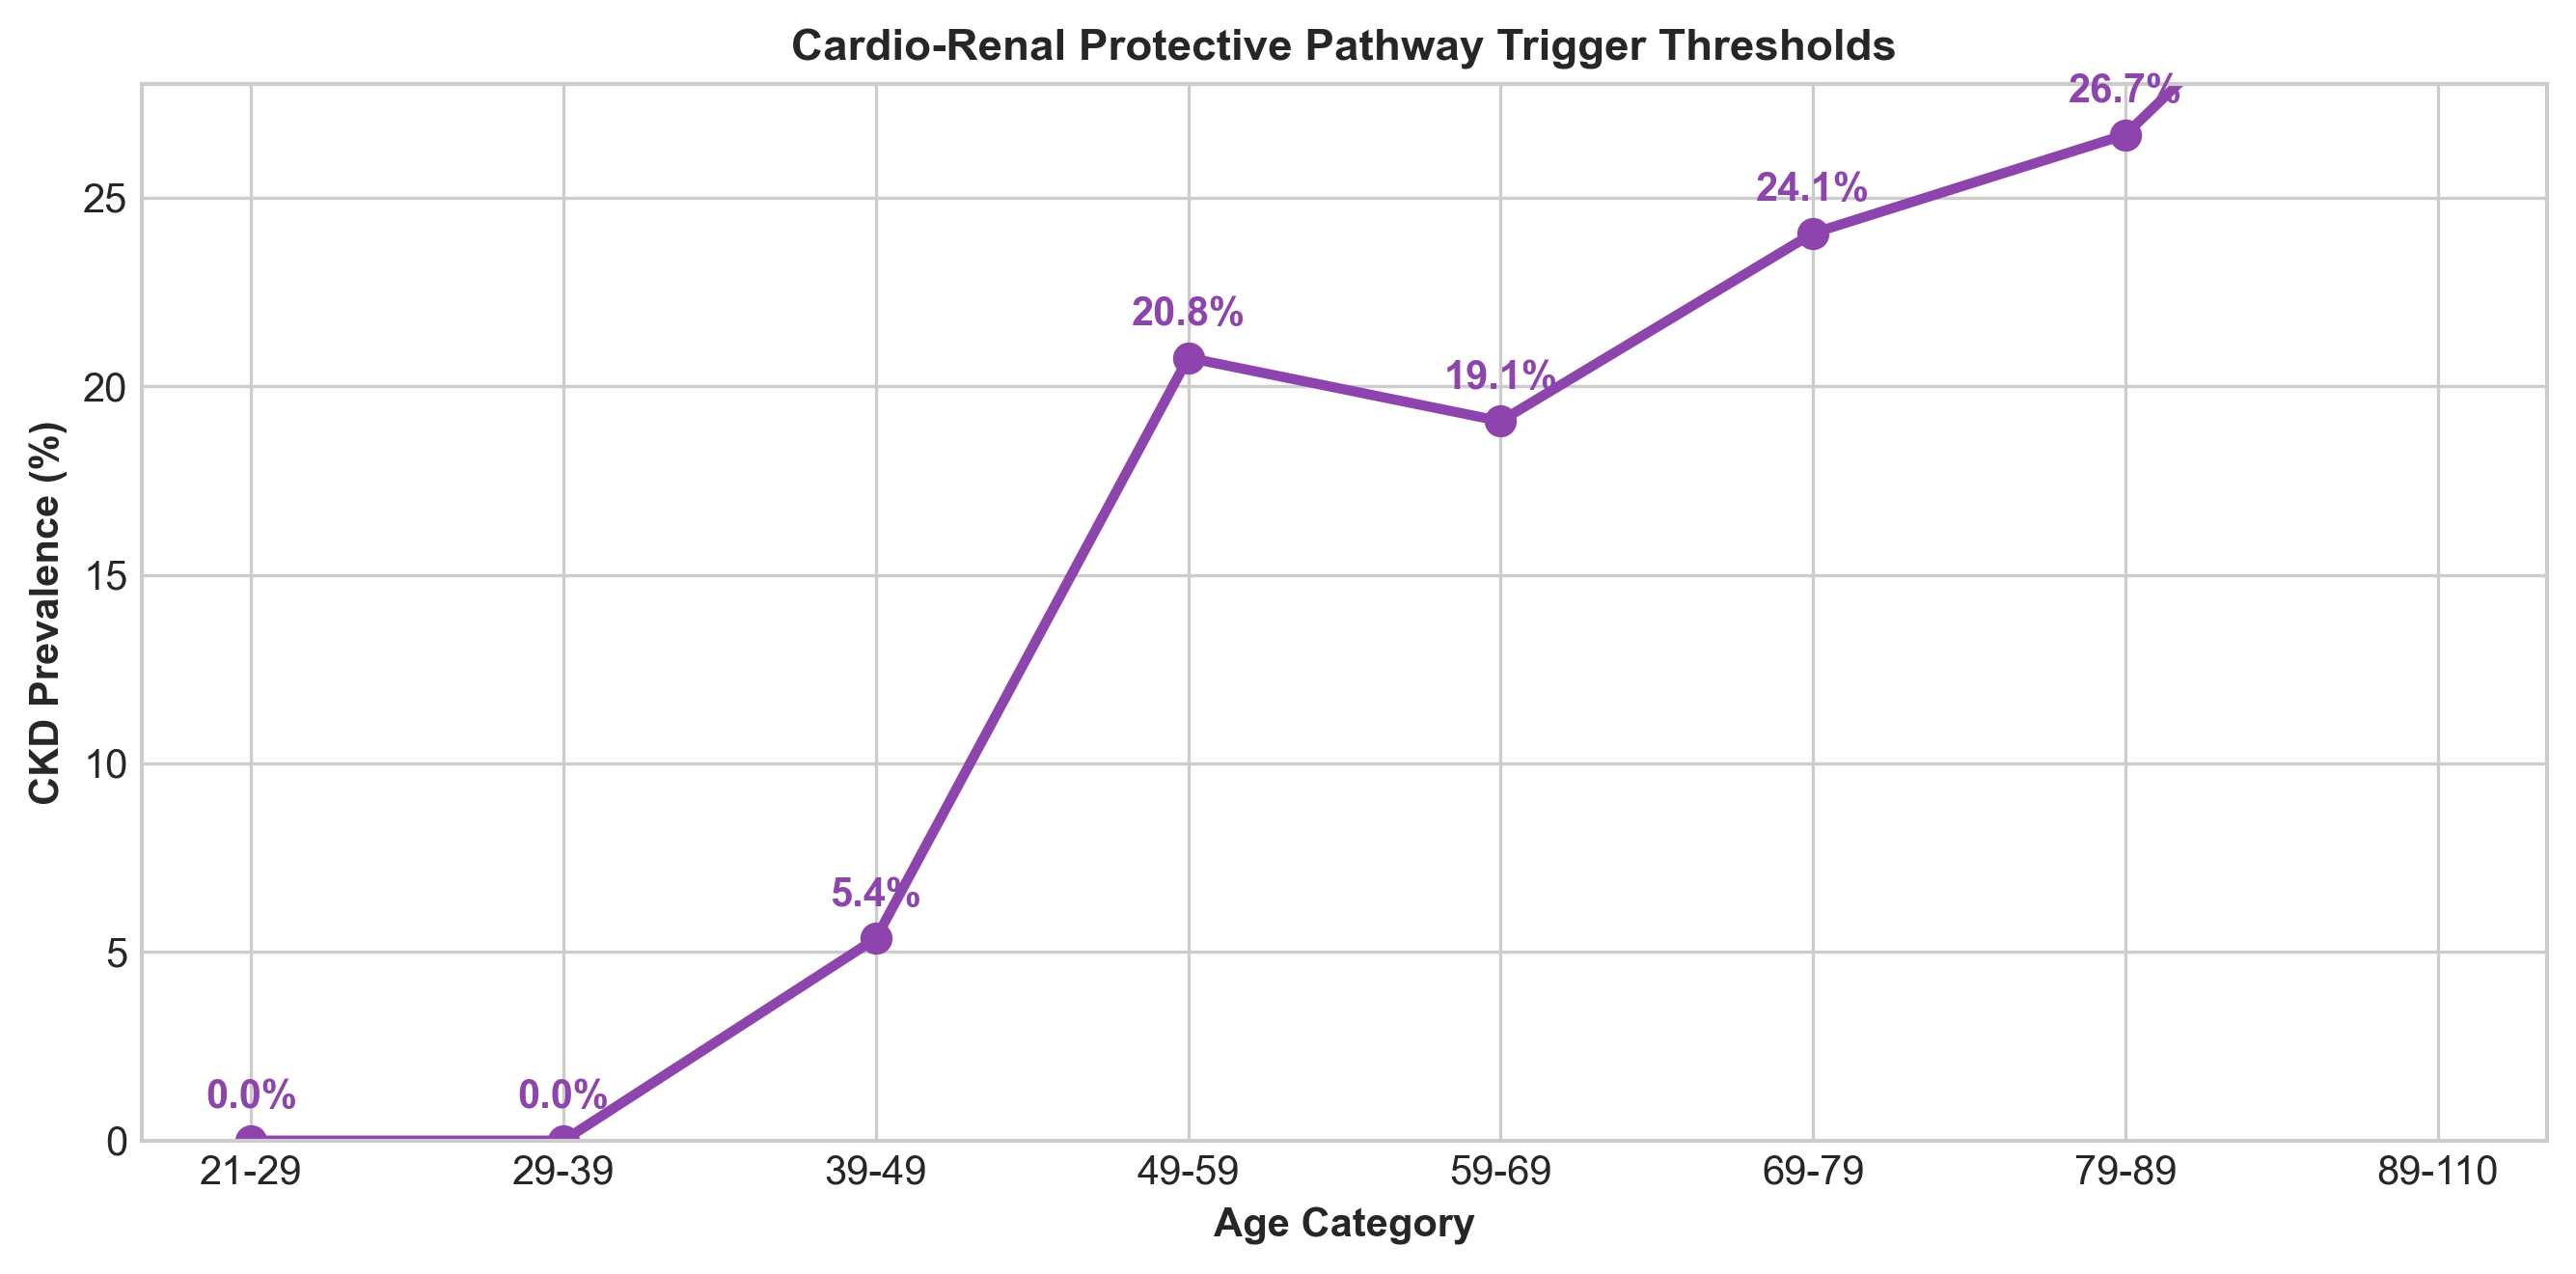

In [10]:
# Prescriptive Action Code - Q4
q4_data = (
    df.groupby('agecat')['moderate_to_severe_chronic_kidney_disease'].mean()
    * 100
)

plt.figure(figsize=(9, 4.5), dpi=300)
plt.plot(
    q4_data.index,
    q4_data.values,
    marker='o',
    linewidth=2.5,
    color='#8e44ad',
    markersize=7,
)
plt.title(
    'Cardio-Renal Protective Pathway Trigger Thresholds',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontweight='bold')
plt.ylim(0, 28)
for idx, val in zip(q4_data.index, q4_data.values):
  plt.annotate(
      f'{val:.1f}%',
      (idx, val),
      textcoords='offset points',
      xytext=(0, 8),
      ha='center',
      fontweight='bold',
      color='#8e44ad',
  )
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>CKD rates jump from 5.4% in patients aged 39–49 to 20.8% in the 49–59 age bracket, peaking at 24.1% in patients aged 69–79.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Implement automated clinical decision alerts for cardio-renal protocol initiation and baseline serum creatinine monitoring for all cardiac admissions aged 50 and above.

<p style="font-family: Cambria; font-size: 16px;"><b>Acute Hemodynamic Deterioration Escalation Matrix

<p style="font-family: Cambria; font-size: 16px;"><b>Question 5:</b></p>How should a hospital adjust nursing care and monitoring levels for heart patients based on their short-term severity (Killip Grade) and long-term symptom level (NYHA Class)? 

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Misinterpreting functional severity (NYHA) as acute hemodynamic stability (Killip Grade) can lead to unexpected ICU transfers.

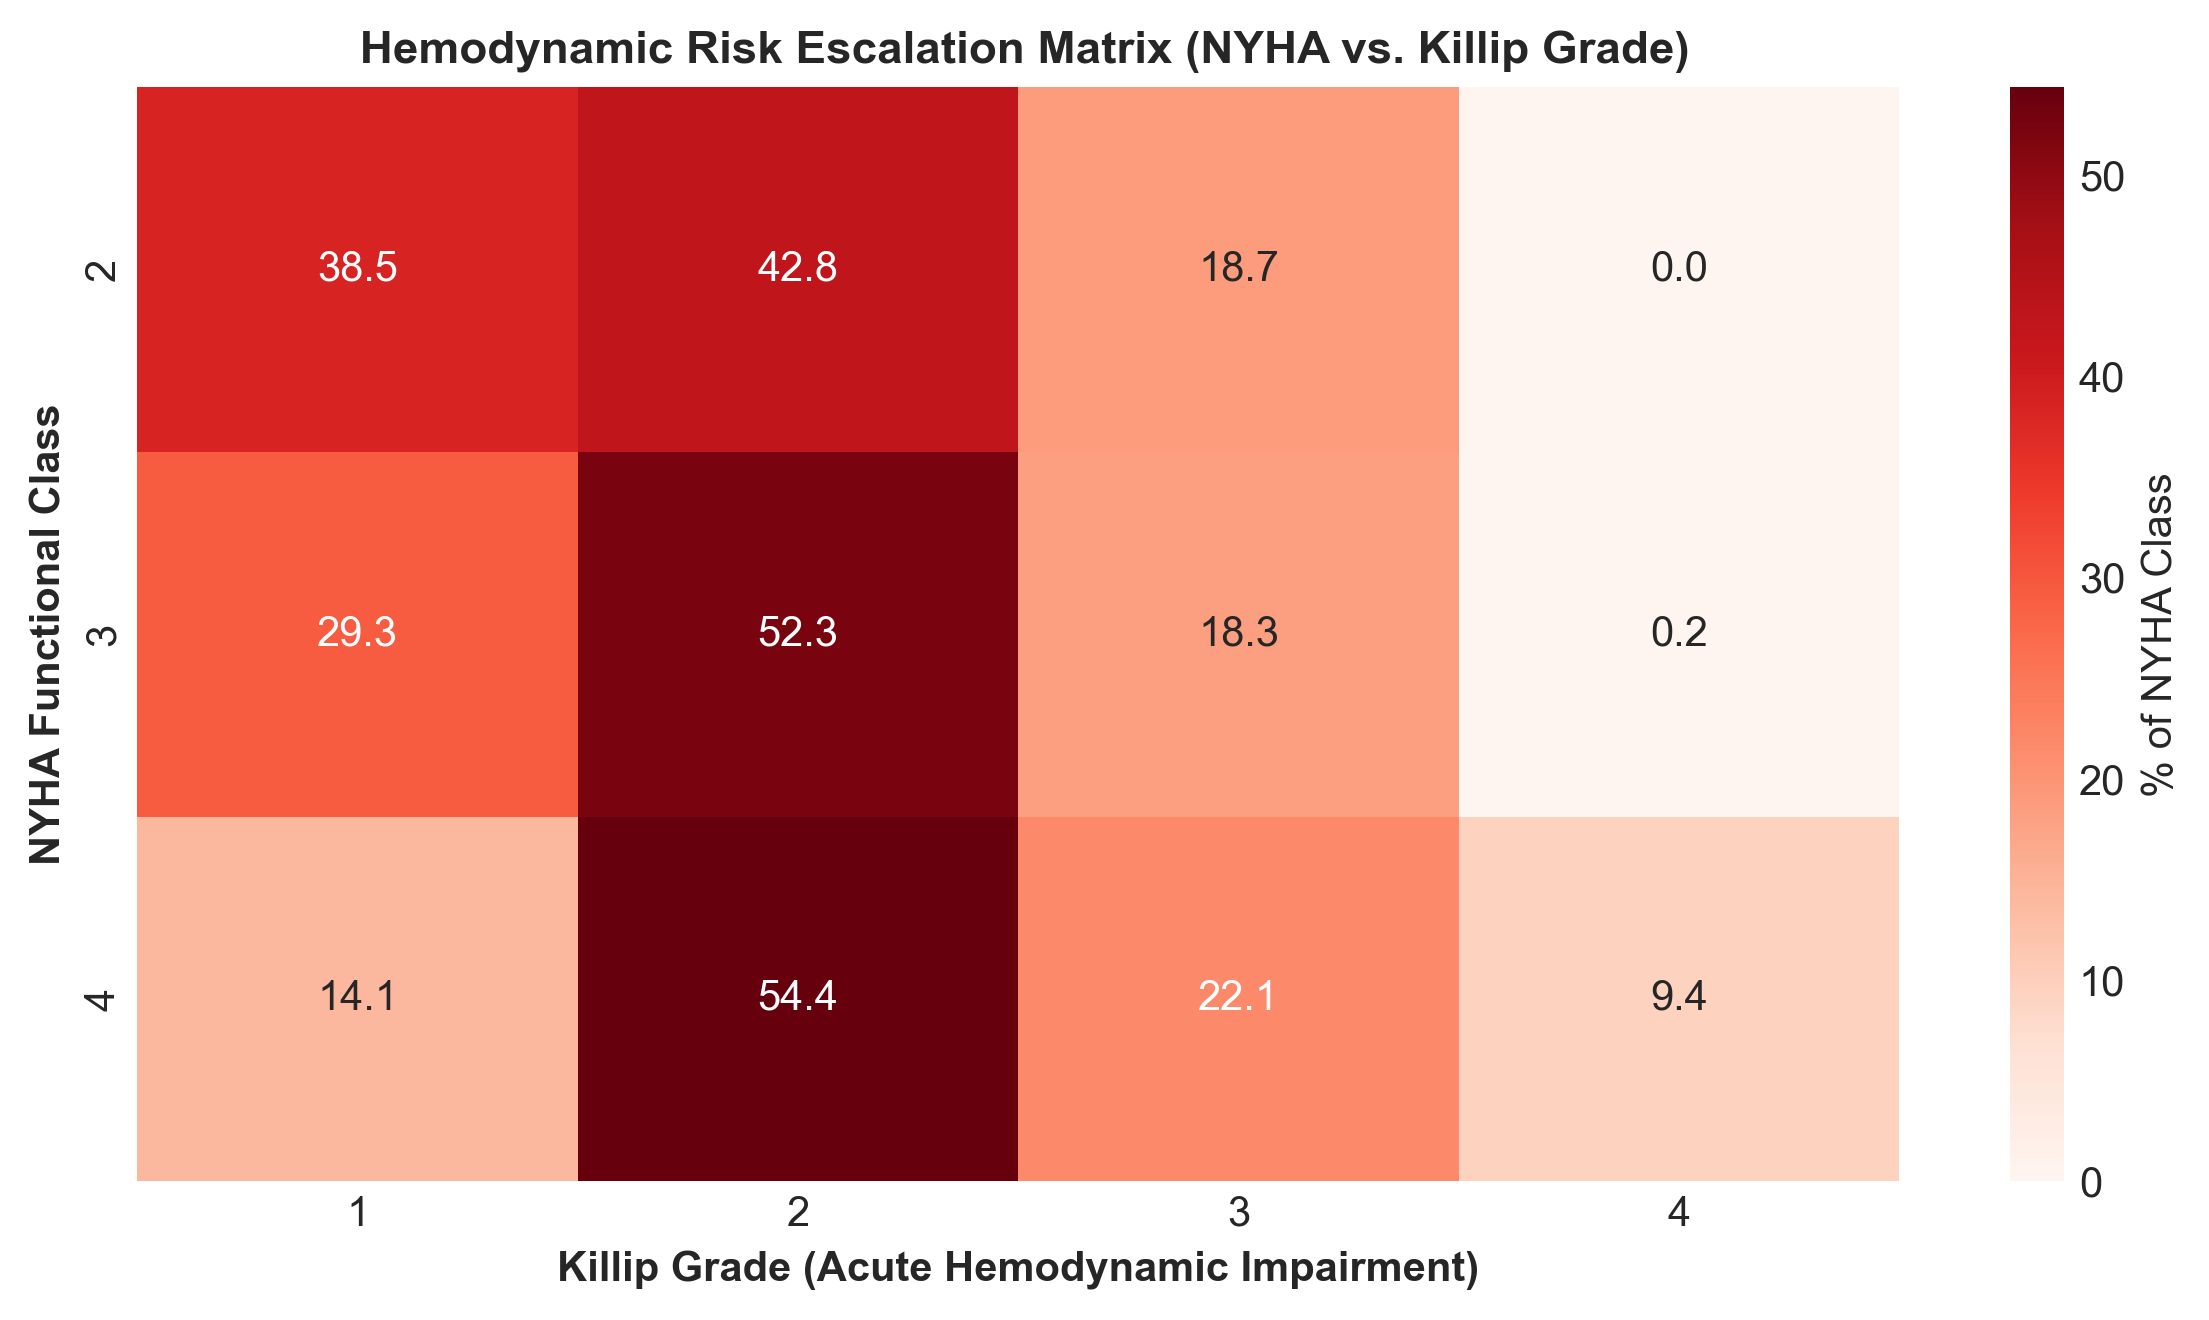

In [11]:
# Prescriptive Action Code - Q5
import seaborn as sns

ct = (
    pd.crosstab(
        df['nyha_cardiac_function_classification'],
        df['killip_grade'],
        normalize='index',
    )
    * 100
)

plt.figure(figsize=(8, 4.5), dpi=300)
sns.heatmap(
    ct,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    cbar_kws={'label': '% of NYHA Class'},
)
plt.title(
    ' Hemodynamic Risk Escalation Matrix (NYHA vs. Killip Grade)',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Killip Grade (Acute Hemodynamic Impairment)', fontweight='bold')
plt.ylabel('NYHA Functional Class', fontweight='bold')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>9.4% of NYHA Class 4 patients are in Killip Grade 4 (cardiogenic shock), requiring immediate intensive care monitoring.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Enforce direct ICU/CCU placement rules for any patient with Killip Grade $\ge$ 3, regardless of whether their chronic NYHA class was low.

<p style="font-family: Cambria; font-size: 16px;"><b>Post-Discharge Readmission Prevention Triad Tracking

<p style="font-family: Cambria; font-size: 16px;"><b>Question 7:</b></p>Which combination of health conditions places a heart failure patient at highest risk, requiring a nurse home visit within 48 hours of leaving the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Readmissions are often driven by co-occurring systemic diseases rather than primary cardiac conditions alone.

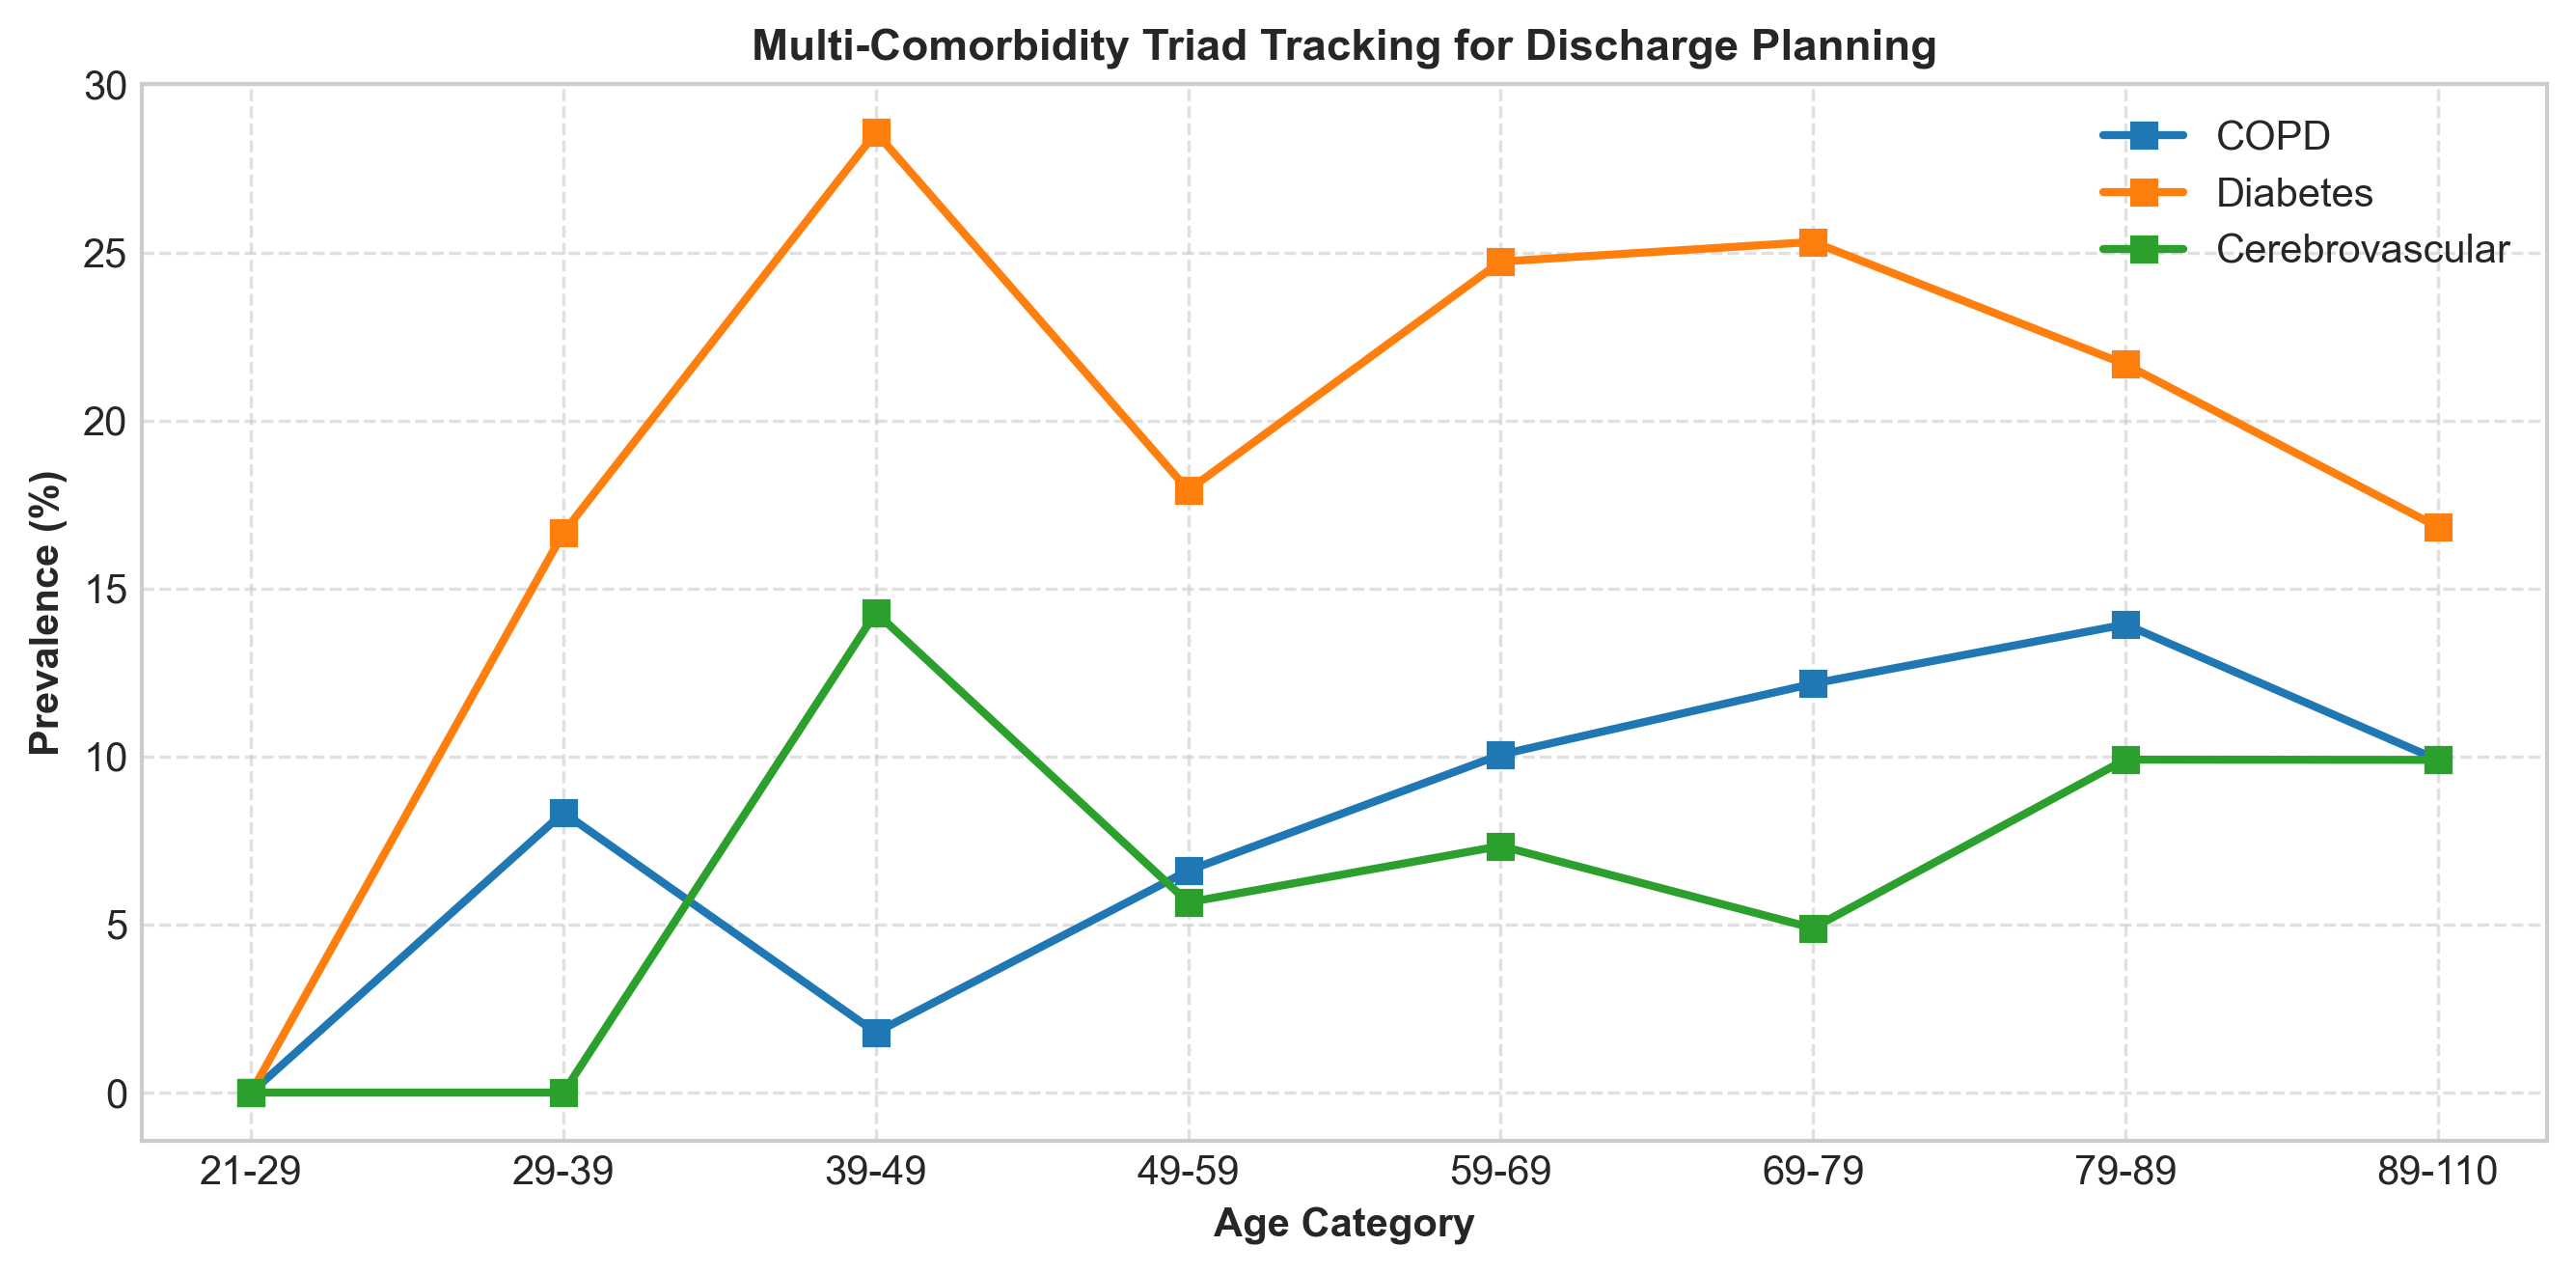

In [12]:
# 1. Calculate prevalence percentages
q7_data = (
    df.groupby('agecat')[
        [
            'chronic_obstructive_pulmonary_disease',
            'diabetes',
            'cerebrovascular_disease',
        ]
    ].mean()
    * 100
)
q7_data.columns = ['COPD', 'Diabetes', 'Cerebrovascular']

# 2. Create the figure with figure size and DPI set HERE
plt.figure(figsize=(9, 4.5), dpi=300)

# 3. Plot without passing dpi inside plot()
ax = q7_data.plot(kind='line', marker='s', linewidth=2, ax=plt.gca())

plt.title(
    'Multi-Comorbidity Triad Tracking for Discharge Planning',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Prevalence (%)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Diabetes peaks at 28.6% in middle-aged cohorts (39–49), while COPD steadily increases with age, reaching 13.9% in patients aged 79–89.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Trigger mandatory post-discharge home health visits within 48 hours for any patient presenting with the "Triad Risk" (Heart Failure + Diabetes + COPD).

<p style="font-family: Cambria; font-size: 16px;"><b>Gender-Specific Clinical Management Guidelines

<p style="font-family: Cambria; font-size: 16px;"><b>Question 8:</b></p>How should treatment plans for left, right, or double-sided heart failure be tailored for male versus female patients?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Biological sex differences influence heart failure presentation, vascular compliance, and response to cardiac therapeutics.

In [13]:
# 1. Create figure and set DPI here
plt.figure(figsize=(9, 4.5), dpi=300)

# 2. Plot without passing dpi inside .plot()
ax = q8_data.plot(kind='bar', width=0.7, ax=plt.gca())

plt.title(
    'Comorbidity Burden by Heart Failure Subtype and Age Group',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Mean Comorbidity Burden (CCI)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='HF Type')
plt.tight_layout()
plt.show()

NameError: name 'q8_data' is not defined

<Figure size 2700x1350 with 0 Axes>

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Male patients presenting with Left Heart Failure exhibit the highest overall comorbidity burden (2.01 CCI), whereas female comorbidity burden is highest in Left Heart Failure as well (1.86 CCI), but with lower overall variation across failure types.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Mandate comprehensive multi-organ subspecialty screening specifically for male patients admitted with isolated Left Heart Failure.